# Post-Cavity Experiment Notebook

Comprehensive characterization using the **qubox_v2 v3** modular experiment API
with the unified `run() -> analyze() -> plot()` workflow.

**Sections:**
1. Initialization
2. OPX/Octave Mixer Calibration
3. Readout Characterization
4. Qubit Characterization
5. Pulse Calibration
6. Readout Calibration
7. SPA Benchmarking
8. Storage Cavity
9. Quantum State Tomography
10. Utility: Continuous-Wave Output

In [1]:
import sys
import numpy as np

sys.path.insert(0, r"E:\qubox")

from qualang_tools.units import unit

from qubox_v2.experiments.session import SessionManager
from qubox_v2.experiments import (
    # Spectroscopy
    ResonatorSpectroscopy,
    ResonatorPowerSpectroscopy,
    ResonatorSpectroscopyX180,
    ReadoutTrace,
    QubitSpectroscopy,
    QubitSpectroscopyEF,
    # Time domain
    PowerRabi,
    TemporalRabi,
    T1Relaxation,
    T2Ramsey,
    T2Echo,
    # Calibration
    IQBlob,
    ReadoutGEDiscrimination,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    AllXY,
    DRAGCalibration,
    QubitPulseTrain,
    RandomizedBenchmarking,
    # Cavity / Fock
    StorageSpectroscopy,
    NumSplittingSpectroscopy,
    StorageChiRamsey,
    FockResolvedSpectroscopy,
    FockResolvedT1,
    FockResolvedRamsey,
    FockResolvedPowerRabi,
    # Tomography
    QubitStateTomography,
    StorageWignerTomography,
    SNAPOptimization,
    # SPA
    SPAFluxOptimization,
    SPAPumpFrequencyOptimization,
)
from qubox_v2.experiments.calibration import ReadoutConfig

u = unit()

2026-02-21 16:30:48,092 - qm - INFO     - Starting session: 177e8acf-7cb7-47c8-b347-8b361e25c564


## 1. Initialization

Create a `SessionManager` which wires up hardware, pulses, calibration,
and device connections. All experiment classes accept it as their context.

In [2]:
experiment_path = r"E:\qubox\seq_1_device"

session = SessionManager(
    experiment_path,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
)

# Open QM connection and build element table (required before hardware ops)
session.open()

attr = session.attributes
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

# Uncomment to run in simulation mode:
# session.hw.set_exec_mode("simulate")

[INFO] 2026-02-21 16:30:51,385 qubox.experiments.session: SessionManager initialising at E:\qubox\seq_1_device
2026-02-21 16:30:54,494 - qm - INFO     - Performing health check
2026-02-21 16:30:54,498 - qm - INFO     - Health check passed
[INFO] 2026-02-21 16:30:54,513 qubox.calibration.store: Loading calibration from E:\qubox\seq_1_device\config\calibration.json
[INFO] 2026-02-21 16:30:57,242 qubox.experiments.session: SessionManager ready.
2026-02-21 16:30:58,437 - qm - WARNING  - Open QM ended with warning 0: Opening a new Quantum Machine and closing Quantum Machines: 
2026-02-21 16:30:58,437 - qm - WARNING  - Open QM ended with warning 0: Quantum Machine qm-1771712890191 is canceling running job 1771622592454.
[INFO] 2026-02-21 16:30:58,670 qubox.experiments.session: Loaded measureMacro state from E:\qubox\seq_1_device\measureConfig.json
Resonator: 8.5962 GHz
Qubit:     6.1504 GHz
Storage:   5.2409 GHz


## 2. OPX/Octave Mixer Calibration

Calibrate IQ mixer offsets (DC offset, gain imbalance, phase imbalance) for
each element. Run this before any measurements to ensure clean signal generation.

In [ ]:
hw = session.hw

# Gather elements and their frequencies
elements = [attr.ro_el, attr.qb_el, attr.st_el]
el_los = hw.get_element_lo(elements)
el_ifs = [hw.calculate_el_if_fq(el, fq)
          for el, fq in zip(elements, [attr.ro_fq, attr.qb_fq, attr.st_fq])]

print("Mixer calibration targets:")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# Run Octave auto-calibration for all elements
#hw.calibrate_element(el=elements, target_LO=el_los, target_IF=el_ifs)
#print("\nOctave mixer calibration complete.")

# --- Manual IQ mixer calibration via SA124B (requires SA connected) ---
# Uncomment below to run manual calibration using an external spectrum analyser.
# The SA124B must be configured in seq_1_device/config/devices.json.
#
from qubox_v2.calibration import MixerCalibrationConfig
#
# # Grid search method (robust, slower):
hw.calibrate_element(el="qubit", method="manual_scan_2d", save_to_db=False)
#
# # Derivative-free minimiser (faster, fewer evaluations):
# hw.calibrate_element(el="qubit", method="manual_minimizer", save_to_db=True)
#
# # With custom SA / grid parameters:
# cfg = MixerCalibrationConfig(sa_avg=10, dc_coarse_n=15, iq_coarse_n=11)
# hw.calibrate_element(el="qubit", method="manual_scan_2d",
#                      mixer_cal_config=cfg, save_to_db=True)

Mixer calibration targets:
  resonator             LO=8.8000 GHz  IF=-203.78 MHz
  qubit                 LO=6.2000 GHz  IF=-49.62 MHz
  storage               LO=5.4000 GHz  IF=-159.07 MHz
2026-02-21 16:28:32,308 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 16:28:32,383 - qm - INFO     - Executing program


## 3. Readout Characterization

### 3.1 Readout Trace

Acquire raw ADC traces to verify readout signal level and timing.

2026-02-21 02:04:24,327 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:04:24,409 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 9999/10000 [00:01<00:00, 6623.28it/s]

[INFO] 2026-02-21 02:04:25,995 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592417
No errors


[INFO] 2026-02-21 02:04:26,038 qubox.hardware.program_runner: Job halted successfully.


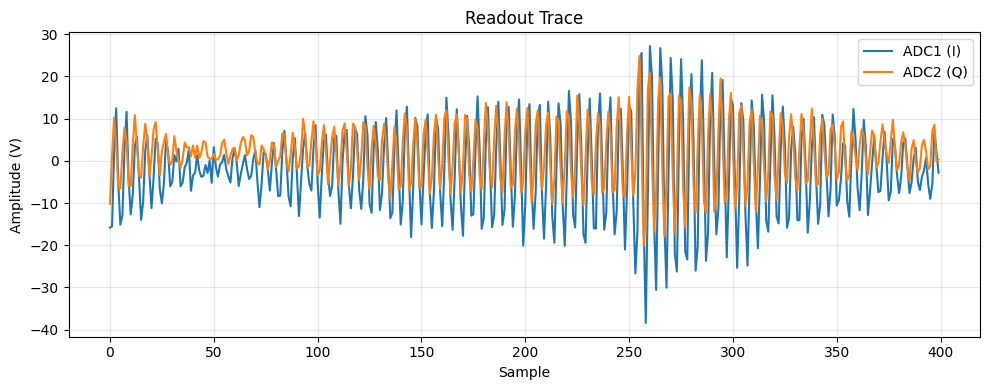

{'trace_length': 400}


In [3]:
trace = ReadoutTrace(session)
result = trace.run(attr.ro_fq, n_avg=10000)

analysis = trace.analyze(result)
trace.plot(analysis)
print(analysis.metrics)

### 3.2 Resonator Spectroscopy

Sweep readout frequency to locate resonator resonance. The `analyze()` method
fits a Lorentzian and extracts `f0` and `kappa`.

2026-02-21 02:04:32,861 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:04:32,933 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 9999/10000 [00:06<00:00, 1488.63it/s]

[INFO] 2026-02-21 02:04:39,712 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592418
No errors


[INFO] 2026-02-21 02:04:39,738 qubox.hardware.program_runner: Job halted successfully.


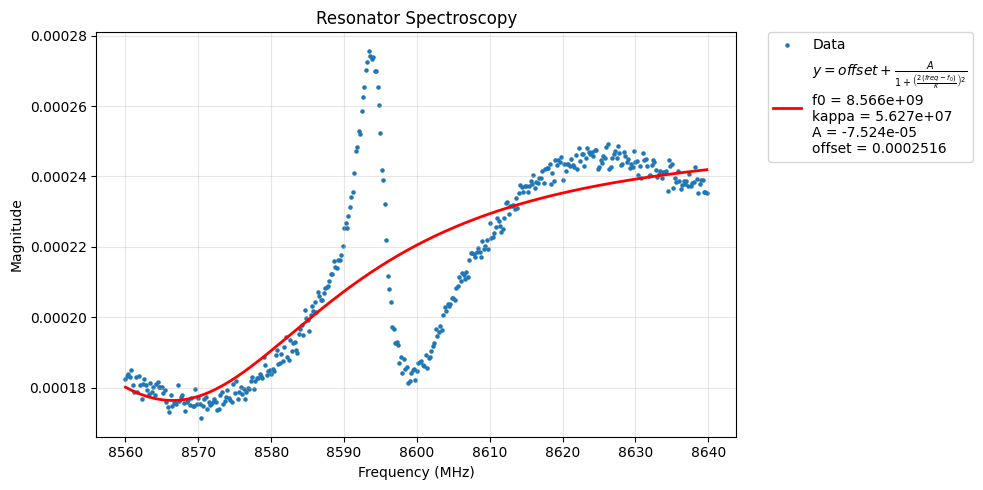

f0 = 8566.4554 MHz
kappa = 56266.9 kHz


In [4]:
spec = ResonatorSpectroscopy(session)
result = spec.run(
    "readout",
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec.analyze(result, update_calibration=True)
spec.plot(analysis)
print(f"f0 = {analysis.metrics['f0'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 3.3 Resonator Power Spectroscopy

2D sweep of readout frequency vs gain to find optimal readout power.

2026-02-21 02:18:49,414 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:18:49,509 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:28<00:00, 176.07it/s]

[INFO] 2026-02-21 02:19:17,969 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592431
No errors


[INFO] 2026-02-21 02:19:17,982 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 02:19:18,004 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\cavityPowerSpectroscopy_20260221_021917.npz


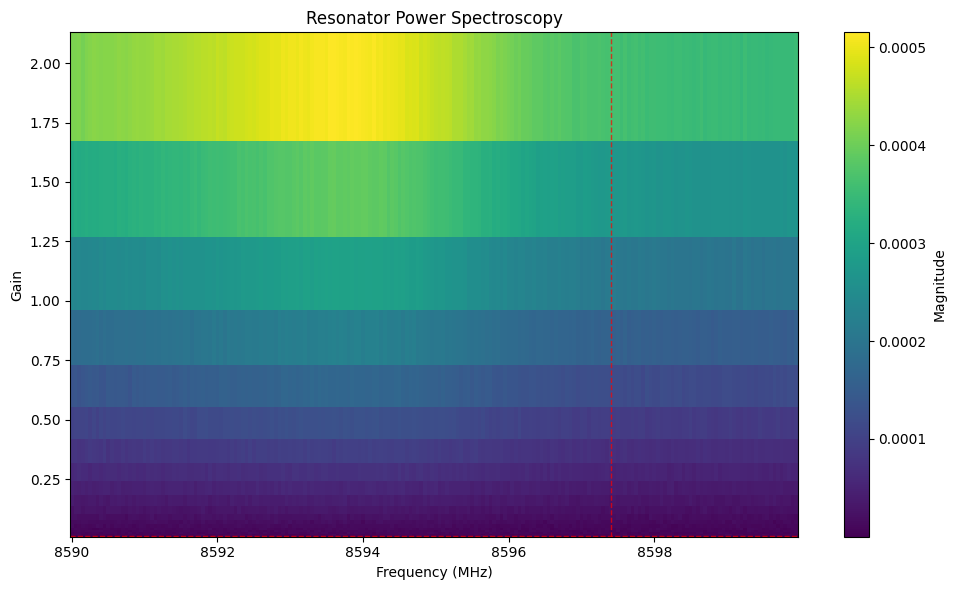

Optimal gain: 0.013180576316170457
Optimal freq: 8597400000.0


In [6]:
pspec = ResonatorPowerSpectroscopy(session)
result = pspec.run(
    "readout",
    rf_begin=8590 * u.MHz,
    rf_end=8600 * u.MHz,
    df=50 * u.kHz,
    g_min=0.01,
    g_max=1.9,
    N_a=20,
    n_avg=5000,
)

analysis = pspec.analyze(result)
pspec.plot(analysis)
print(f"Optimal gain: {analysis.metrics.get('optimal_gain', 'N/A')}")
print(f"Optimal freq: {analysis.metrics.get('optimal_freq', 'N/A')}")

### 3.4 Resonator Spectroscopy with X180

Measure resonator with ground and excited qubit states to extract
dispersive shift chi.

2026-02-21 02:05:30,048 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:05:30,184 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 9999/10000 [00:36<00:00, 275.64it/s]

[INFO] 2026-02-21 02:06:06,553 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592420
No errors
[INFO] 2026-02-21 02:06:06,579 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 02:06:06,584 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\resonatorX180_20260221_020606.npz


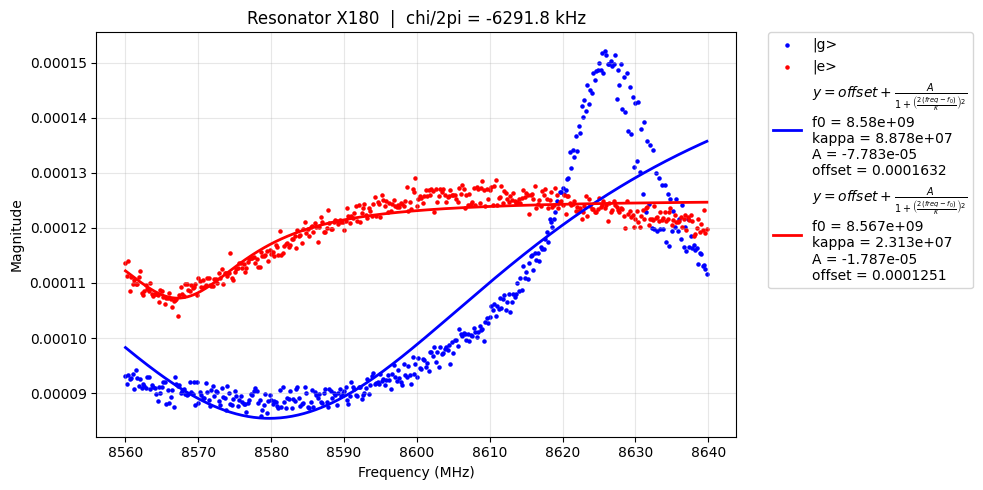

f0_g = 8579.7477 MHz
f0_e = 8567.1641 MHz
chi = -6291.8 kHz


In [6]:
spec_x180 = ResonatorSpectroscopyX180(session)
result = spec_x180.run(
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec_x180.analyze(result, update_calibration=True)
spec_x180.plot(analysis)
print(f"f0_g = {analysis.metrics.get('f0_g', 0) / 1e6:.4f} MHz")
print(f"f0_e = {analysis.metrics.get('f0_e', 0) / 1e6:.4f} MHz")
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")

## 4. Qubit Characterization

### 4.1 Qubit Spectroscopy

Sweep qubit drive frequency to locate the qubit transition.

2026-02-21 02:07:21,649 - qm - INFO     - Sending program to QOP for compilation


2026-02-21 02:07:21,758 - qm - WARNING  - pulse 'saturation' used in play is not part of element 'qubit' operations
2026-02-21 02:07:21,840 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 999/1000 [00:05<00:00, 189.28it/s]

[INFO] 2026-02-21 02:07:27,127 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592422
No errors
[INFO] 2026-02-21 02:07:27,152 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 02:07:27,155 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\qubitSpectroscopy_20260221_020727.npz


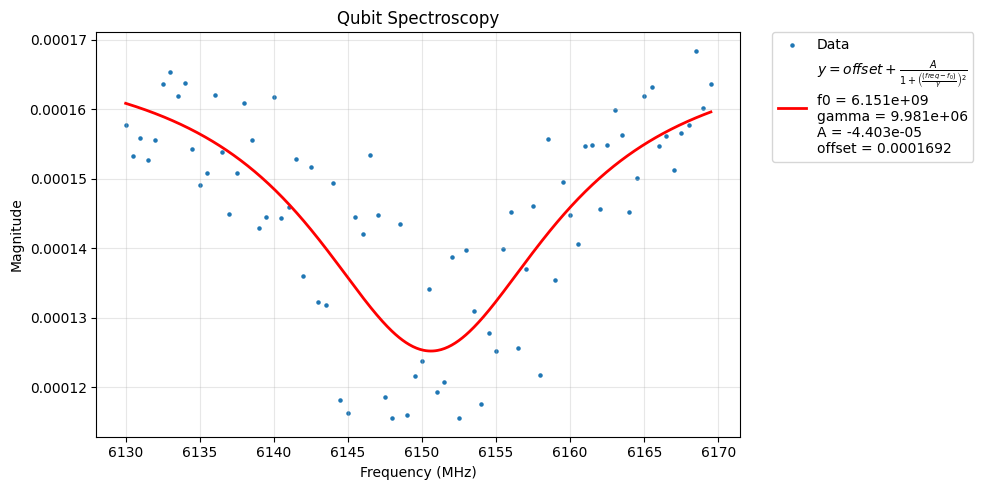

f0 = 6150.6055 MHz


In [8]:
qb_spec = QubitSpectroscopy(session)
result = qb_spec.run(
    "saturation",
    rf_begin=6130 * u.MHz,
    rf_end=6170 * u.MHz,
    df=500 * u.kHz,
    qb_gain=1.0,
    qb_len=1000,
    n_avg=1000,
)

analysis = qb_spec.analyze(result, update_calibration=True)
qb_spec.plot(analysis)
print(f"f0 = {analysis.metrics['f0'] / 1e6:.4f} MHz")

### 4.2 Power Rabi

Sweep qubit drive amplitude to calibrate the pi pulse gain.

2026-02-21 16:31:06,136 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 16:31:06,237 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:30<00:00, 162.50it/s]


[INFO] 2026-02-21 16:31:37,082 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592455
No errors
[INFO] 2026-02-21 16:31:37,111 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 16:31:37,114 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\powerRabi_20260221_163137.npz


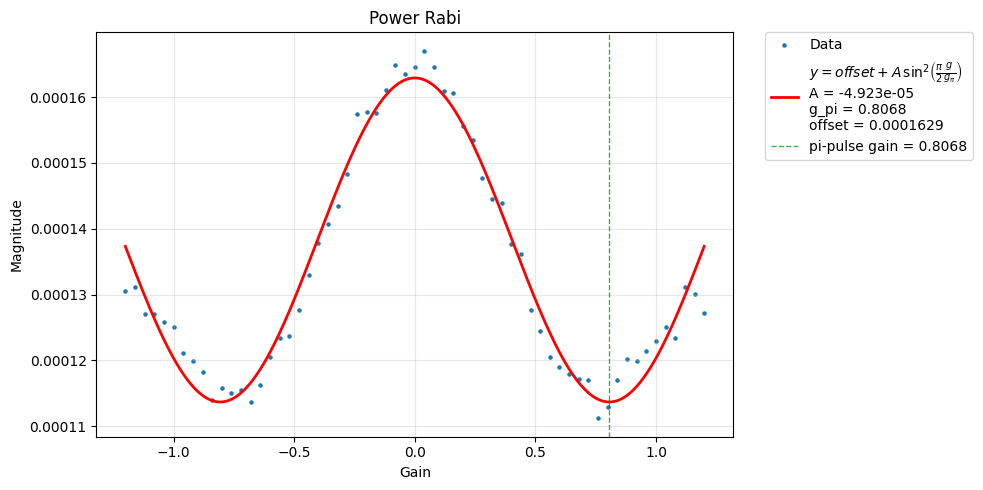

g_pi = 0.8068


In [3]:
rabi = PowerRabi(session)
result = rabi.run(
    max_gain=1.2,
    dg=0.04,
    op="ref_r180",
    n_avg=5000,
)

analysis = rabi.analyze(result, update_calibration=True)
rabi.plot(analysis)
print(f"g_pi = {analysis.metrics.get('g_pi', 'N/A'):.4f}")

### 4.3 Temporal Rabi

Sweep pulse duration at fixed amplitude to measure Rabi frequency.

2026-02-21 02:07:58,397 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:07:58,684 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:37<00:00, 134.53it/s]

[INFO] 2026-02-21 02:08:35,991 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592424
No errors
[INFO] 2026-02-21 02:08:36,020 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 02:08:36,023 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\temporalRabi_20260221_020836.npz


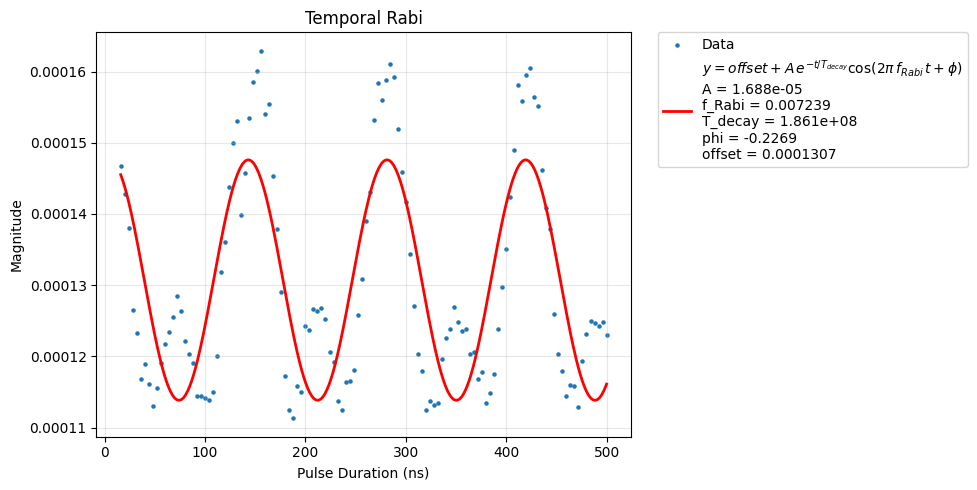

f_Rabi = 0.007239019883032073 Hz
pi_length = 69.0701238674557 ns


In [10]:
trabi = TemporalRabi(session)
result = trabi.run(
    pulse="const_x180",
    pulse_len_begin=16,
    pulse_len_end=500,
    dt=4,
    n_avg=5000,
)

analysis = trabi.analyze(result)
trabi.plot(analysis)
print(f"f_Rabi = {analysis.metrics.get('f_Rabi', 'N/A')} Hz")
print(f"pi_length = {analysis.metrics.get('pi_length', 'N/A')} ns")

### 4.4 T1 Relaxation

Measure energy relaxation time after a pi pulse.

2026-02-21 14:35:01,620 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 14:35:01,721 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:48<00:00, 41.44it/s]

[INFO] 2026-02-21 14:35:50,045 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592448
No errors
[INFO] 2026-02-21 14:35:50,076 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 14:35:50,078 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\T1Relaxation_20260221_143550.npz


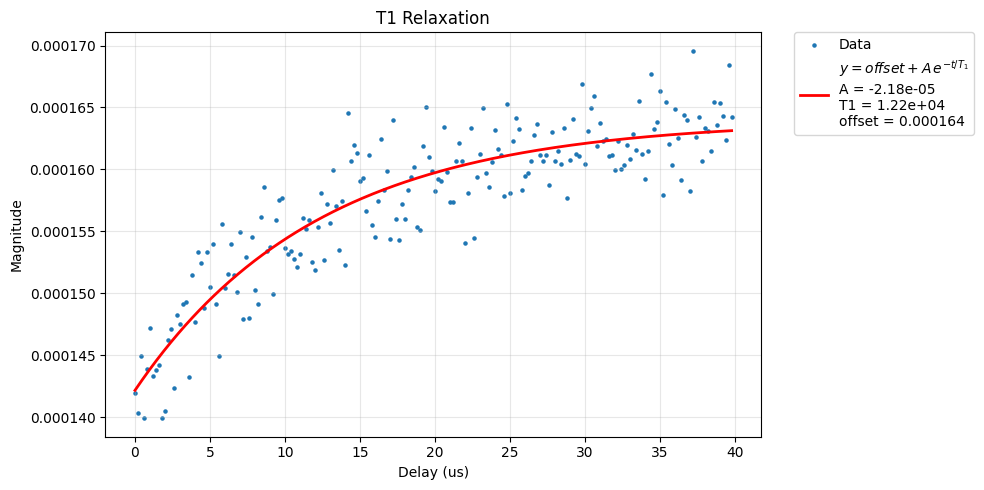

T1 = 12.20 us


In [6]:
t1 = T1Relaxation(session)
result = t1.run(
    delay_end=40 * u.us,
    dt=200,  # ns
    n_avg=2000,
)

# p0: [A, T1(ns), offset]  -- T1 ~ 10 us = 10000 ns
analysis = t1.analyze(result, update_calibration=True,
                      p0=[0, 10000, 0])
t1.plot(analysis)
print(f"T1 = {analysis.metrics['T1'] / 1e3:.2f} us")

### 4.5 T2 Ramsey

Ramsey interferometry with intentional detuning to measure T2*.

In [ ]:
t2r = T2Ramsey(session)
qb_det = 0.2 * u.MHz  # 200 kHz detuning
result = t2r.run(
    qb_detune=qb_det,
    delay_end=40 * u.us,
    dt=100,  # ns
    n_avg=4000,
)

# p0: [A, T2(ns), n, f_det(1/ns), phi, offset]
# T2 ~ 20 us = 20000 ns;  f_det = 0.2 MHz = 0.0002 GHz = 0.0002/ns
analysis = t2r.analyze(result, update_calibration=True,
                       p0=[0, 20000, 1.0, qb_det / 1e9, 0.0, 0])
t2r.plot(analysis)
print(f"T2* = {analysis.metrics['T2_star'] / 1e3:.2f} us")

### 4.6 T2 Echo

Hahn echo measurement for T2_echo (removing low-frequency dephasing).

In [ ]:
t2e = T2Echo(session)
result = t2e.run(
    delay_end=40 * u.us,
    dt=100,  # ns
    n_avg=4000,
)

# p0: [A, T2_echo(ns), n, offset]  -- T2_echo ~ 40 us = 40000 ns
analysis = t2e.analyze(result, update_calibration=True,
                       p0=[-1, 40000, 1.0, 0])
t2e.plot(analysis)
print(f"T2_echo = {analysis.metrics['T2_echo'] / 1e3:.2f} us")

### 4.7 Primitive Pulse Waveform Update

Apply the Power Rabi calibration (`g_pi`) to the reference pulse and regenerate
all qubit rotation waveforms. The flow:

1. Retrieve `ref_r180` reference attributes (amplitude, length=16 ns, sigma=length/6, drag_coeff=0)
2. Scale the stored reference amplitude by `g_pi` from Power Rabi
3. Generate DRAG Gaussian I/Q waveforms at the calibrated amplitude
4. Call `register_rotations_from_ref_iq()` to derive all standard gates
   (x180, x90, y180, y90, etc.) from the reference, then push to QM config

In [4]:
from qubox_v2.tools.waveforms import drag_gaussian_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq
from qubox_v2.pulses.manager import BASE_AMPLITUDE

# --- Reference pulse defaults ---
ref_pulse_len = 16        # ns (primitive pulse length)
ref_drag_coeff = 0.0      # no DRAG by default (calibrated later in sec 5.1)
ref_sigma = ref_pulse_len / 6  # sigma = length / 6

# --- Retrieve g_pi from Power Rabi calibration ---
cal = session.calibration.get_pulse_calibration("x180")
g_pi = cal.amplitude if cal and cal.amplitude else 1.0

# --- Retrieve or initialise the reference amplitude ---
ref_cal = session.calibration.get_pulse_calibration("ref_r180")
if ref_cal and ref_cal.amplitude:
    ref_amplitude = ref_cal.amplitude
else:
    ref_amplitude = BASE_AMPLITUDE

# --- Store reference pulse attributes in CalibrationStore ---
session.calibration.set_pulse_calibration(
    "ref_r180",
    amplitude=ref_amplitude,
    length=ref_pulse_len,
    drag_coeff=ref_drag_coeff,
    sigma=ref_sigma,
    element=attr.qb_el,
)

# --- Apply calibration: scale reference amplitude by g_pi ---
calibrated_amp = ref_amplitude * g_pi

anharmonicity = attr.anharmonicity or -200e6  # Hz

print(f"Reference amplitude:  {ref_amplitude:.4f}")
print(f"g_pi (from Rabi):     {g_pi:.4f}")
print(f"Calibrated amplitude: {calibrated_amp:.4f}  (ref * g_pi)")
print(f"Pulse length:         {ref_pulse_len} ns")
print(f"Sigma:                {ref_sigma:.2f} ns")
print(f"DRAG coeff:           {ref_drag_coeff}")
print(f"Anharmonicity:        {anharmonicity / 1e6:.1f} MHz")

# --- Generate DRAG Gaussian waveforms for the reference x180 ---
ref_I, ref_Q = drag_gaussian_pulse_waveforms(
    amplitude=calibrated_amp,
    length=ref_pulse_len,
    sigma=ref_sigma,
    alpha=ref_drag_coeff,
    anharmonicity=anharmonicity,
)

print(f"\nWaveform samples: {len(ref_I)}")
print(f"Max |I|:          {max(abs(v) for v in ref_I):.4f}")
print(f"Max |Q|:          {max(abs(v) for v in ref_Q):.4f}")

# --- Register all rotation gates from reference IQ ---


pom = session.pulse_mgr
created = register_rotations_from_ref_iq(
    pom,
    ref_I=ref_I,
    ref_Q=ref_Q,
    element=attr.qb_el,
    rotations="all",
    make_r0=True,
    override=True,
    persist=False,
)

# Push updated pulses into QM config
session.burn_pulses()

print(f"\nRegistered {len(created)} rotation gates:")
for op_name, (I, Q) in sorted(created.items()):
    print(f"  {op_name:12s}  len={len(I):3d}  "
          f"max|I|={max(abs(v) for v in I):.4f}  "
          f"max|Q|={max(abs(v) for v in Q):.4f}")



Reference amplitude:  0.2400
g_pi (from Rabi):     0.8155
Calibrated amplitude: 0.1957  (ref * g_pi)
Pulse length:         16 ns
Sigma:                2.67 ns
DRAG coeff:           0.0
Anharmonicity:        255.8 MHz

Waveform samples: 16
Max |I|:          0.1886
Max |Q|:          0.0000

Registered 8 rotation gates:
  r0            len= 16  max|I|=0.0000  max|Q|=0.0000
  ref_r180      len= 16  max|I|=0.1886  max|Q|=0.0000
  x180          len= 16  max|I|=0.1886  max|Q|=0.0000
  x90           len= 16  max|I|=0.0943  max|Q|=0.0000
  xn90          len= 16  max|I|=0.0943  max|Q|=0.0000
  y180          len= 16  max|I|=0.0000  max|Q|=0.1886
  y90           len= 16  max|I|=0.0000  max|Q|=0.0943
  yn90          len= 16  max|I|=0.0000  max|Q|=0.0943


## 5. Pulse Calibration

### 5.1 DRAG Calibration

Sweep DRAG coefficient to minimize leakage to the second excited state.

In [ ]:
drag = DRAGCalibration(session)
result = drag.run(
    amps=np.linspace(-2.0, 2.0, 41),
    n_avg=5000,
)

analysis = drag.analyze(result, update_calibration=True)
drag.plot(analysis)
print(f"Optimal alpha = {analysis.metrics.get('optimal_alpha', 'N/A')}")

### 5.2 Qubit Pulse Train

Repeated gate applications to measure amplitude and phase errors.

In [ ]:
ptrain = QubitPulseTrain(session)
result = ptrain.run(
    N_values=list(range(1, 51)),
    rotation_pulse="x180",
    n_avg=5000,
)

analysis = ptrain.analyze(result)
ptrain.plot(analysis)
print(analysis.metrics)

### 5.3 AllXY

21-point gate error diagnostic. Ideal result is the stepped staircase pattern.

2026-02-21 02:08:49,459 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:08:51,063 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:06<00:00, 774.12it/s]

[INFO] 2026-02-21 02:08:57,619 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592425
No errors


[INFO] 2026-02-21 02:08:57,652 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 02:08:57,655 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\allXY_20260221_020857.npz


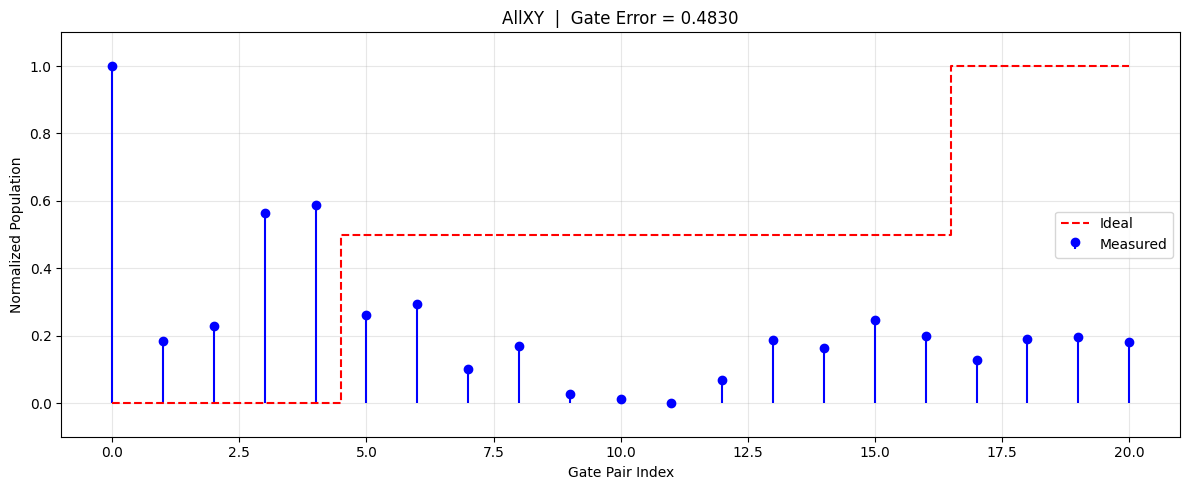

Gate error = 0.4830


In [11]:
allxy = AllXY(session)
result = allxy.run(n_avg=5000)

analysis = allxy.analyze(result)
allxy.plot(analysis)
print(f"Gate error = {analysis.metrics.get('gate_error', 'N/A'):.4f}")

### 5.4 Randomized Benchmarking

Single-qubit Clifford RB for average gate fidelity.

In [ ]:
rb = RandomizedBenchmarking(session)
result = rb.run(
    m_list=[1, 5, 10, 20, 50, 100, 200],
    num_sequence=20,
    n_avg=1000,
)

# p0: [p, A, B]  -- p ~ 0.99 typical
analysis = rb.analyze(result, p0=[0.99, 0.5, 0.5])
rb.plot(analysis)
print(f"p = {analysis.metrics.get('p', 'N/A')}")
print(f"Avg gate fidelity = {analysis.metrics.get('avg_gate_fidelity', 'N/A')}")
print(f"Error per gate = {analysis.metrics.get('error_per_gate', 'N/A')}")

## 6. Readout Calibration

### 6.1 IQ Blob

Acquire IQ blobs for ground and excited states.

2026-02-21 16:32:13,141 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 16:32:13,324 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4927.04it/s]

[INFO] 2026-02-21 16:32:23,482 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592456
No errors


[INFO] 2026-02-21 16:32:23,563 qubox.hardware.program_runner: Job halted successfully.


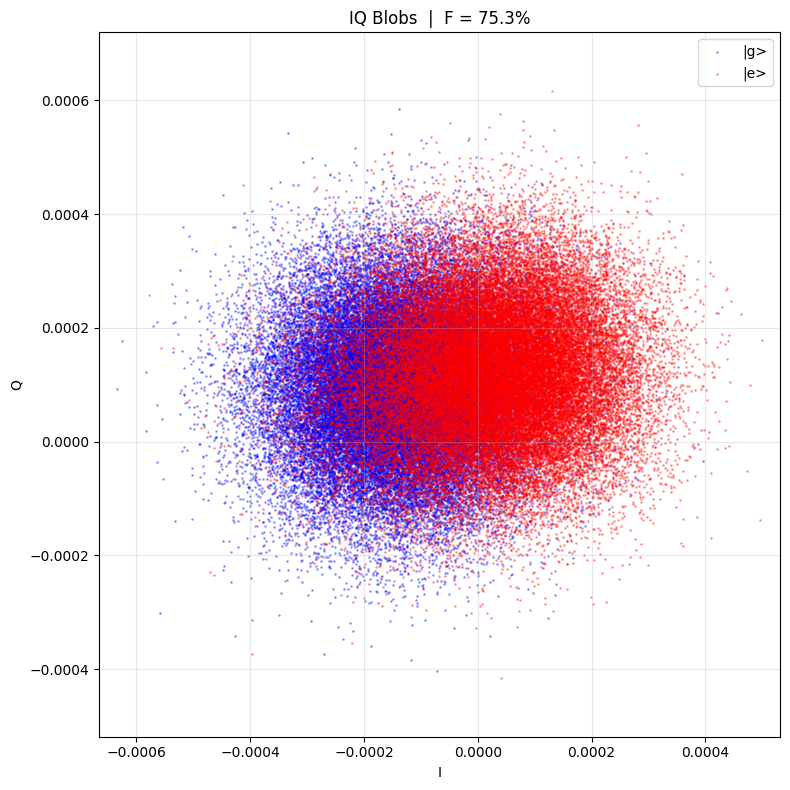

Readout fidelity = 7527.30%


In [4]:
iq = IQBlob(session)
result = iq.run("x180", n_runs=50000)

analysis = iq.analyze(result)
iq.plot(analysis)
print(f"Readout fidelity = {analysis.metrics.get('fidelity', 0):.2%}")

### 6.2 GE Discrimination

Full discrimination analysis with optimal angle, threshold, and confusion matrix.

In [5]:
ge = ReadoutGEDiscrimination(session)
result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50000,
)

analysis = ge.analyze(result, update_calibration=True)
ge.plot(analysis, show_rotated=True, interactive=False)
print(f"Fidelity = {analysis.metrics.get('fidelity', 0):.2%}")
print(f"Angle = {analysis.metrics.get('angle', 0):.3f} rad")
print(f"Threshold = {analysis.metrics.get('threshold', 0):.4f}")

# New diagnostics from the enhanced pipeline
if "gaussianity_g" in analysis.metrics:
    print(f"Gaussianity (g) = {analysis.metrics['gaussianity_g']:.3f}")
    print(f"Gaussianity (e) = {analysis.metrics['gaussianity_e']:.3f}")
if "cv_fidelity" in analysis.metrics:
    print(f"Cross-validated fidelity = {analysis.metrics['cv_fidelity']:.2%}")

[INFO] 2026-02-21 16:32:46,899 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
2026-02-21 16:32:47,019 - qm - INFO     - Sending program to QOP for compilation


C:\Users\jl82323\AppData\Local\Temp\ipykernel_6464\234997048.py:2: DeprecationWarning: Using legacy 'rot_*' weight labels. Please rename to 'cos', 'sin', 'm_sin'.
  result = ge.run(


2026-02-21 16:32:47,192 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4948.11it/s]

[INFO] 2026-02-21 16:32:57,306 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592457
No errors


[INFO] 2026-02-21 16:32:57,384 qubox.hardware.program_runner: Job halted successfully.
[ERROR] 2026-02-21 16:32:59,113 qubox.experiments.calibration.readout: Unexpected error in GE discrimination: float() argument must be a string or a real number, not 'complex'
[WARNING] 2026-02-21 16:32:59,114 qubox.experiments.calibration.readout: Rotated weight construction failed: 'PulseOperationManager' object has no attribute 'burn'


E:\qubox\qubox_v2\experiments\calibration\readout.py:395: UserWarning: Rotated weight construction failed: 'PulseOperationManager' object has no attribute 'burn'
  warnings.warn(f"Rotated weight construction failed: {exc}")


ValidationError: 2 validation errors for DiscriminationParams
sigma_g
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type
sigma_e
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type

### 6.3 Butterfly Measurement

Two successive measurements to quantify QND fidelity, F, Q, and V.

[INFO] 2026-02-21 16:33:28,306 qubox.experiments.calibration.readout: Butterfly measurement: n_samples=50000, policy='BLOBS'
2026-02-21 16:33:28,518 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 16:33:29,128 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:04<00:00, 10110.97it/s]

[INFO] 2026-02-21 16:33:34,201 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592458
No errors


[INFO] 2026-02-21 16:33:34,458 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 16:33:34,856 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260221_163334.npz
[INFO] 2026-02-21 16:33:34,858 qubox.experiments.calibration.readout: Butterfly metrics: F=0.6631, Q=0.9761, V=0.3263, t01=0.0044, t10=0.0434


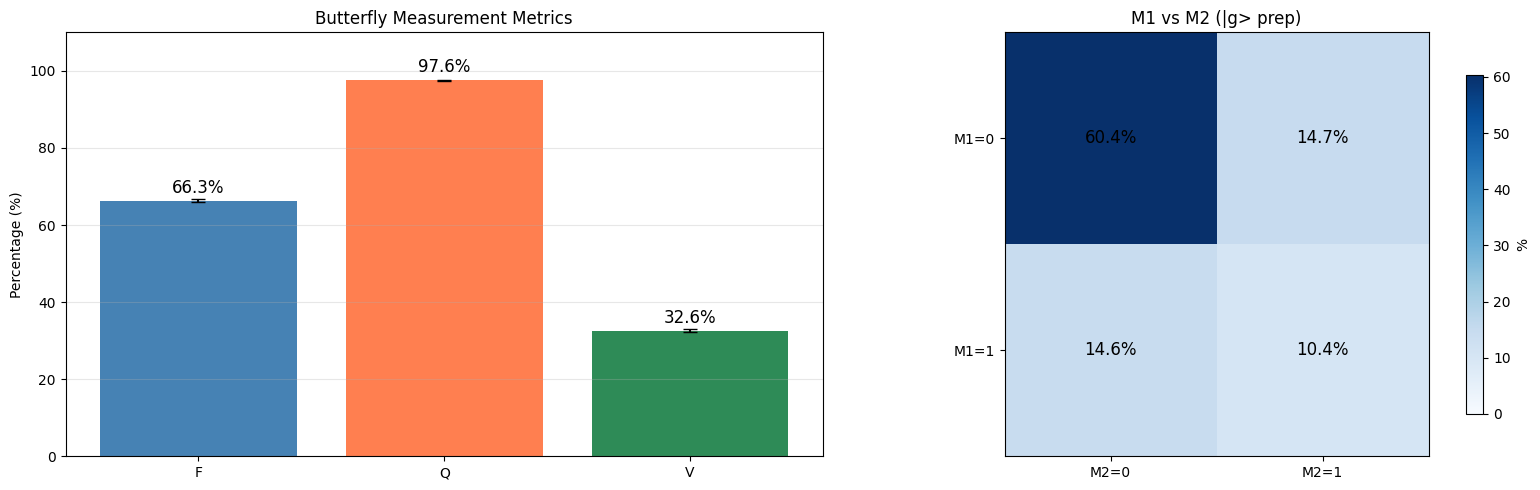

F = 66.31%
Q = 97.61%
V = 0.3263
t01 = 0.0044
t10 = 0.0434
Lambda_M_valid = True


In [6]:
bfly = ReadoutButterflyMeasurement(session)
result = bfly.run(r180="x180", n_samples=50000)

analysis = bfly.analyze(result, update_calibration=True)
bfly.plot(analysis, show_histogram=True)
print(f"F = {analysis.metrics.get('F', 0):.2%}")
print(f"Q = {analysis.metrics.get('Q', 0):.2%}")
print(f"V = {analysis.metrics.get('V', 0):.4f}")

# New diagnostics from the enhanced pipeline
if "t01" in analysis.metrics:
    print(f"t01 = {analysis.metrics['t01']:.4f}")
    print(f"t10 = {analysis.metrics['t10']:.4f}")
if "Lambda_M_valid" in analysis.metrics:
    print(f"Lambda_M_valid = {analysis.metrics['Lambda_M_valid']}")

### 6.4 Full Readout Calibration Pipeline

Automated pipeline: weights optimization -> GE discrimination -> butterfly.

In [ ]:
# --- Option A: Using keyword arguments (backward compatible) ---
cal_full = CalibrateReadoutFull(session)
result = cal_full.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples_disc=50000,
    n_shots_butterfly=50000,
)

# --- Option B: Using ReadoutConfig (recommended for advanced usage) ---
# config = ReadoutConfig(
#     ro_op="readout",
#     drive_frequency=attr.ro_fq,
#     r180="x180",
#     n_samples_disc=50000,
#     n_shots_butterfly=50000,
#     max_iterations=2,              # convergence loop (repeat until fidelity stabilises)
#     adaptive_samples=True,         # auto-increase samples if uncertainty is high
#     gaussianity_warn_threshold=2.0,
#     cv_split_ratio=0.2,            # 80/20 cross-validation for unbiased fidelity
# )
# result = cal_full.run(config=config)

analysis = cal_full.analyze(result, update_calibration=True)
cal_full.plot(analysis)

print("\n--- Calibration Results ---")
print(f"Fidelity:  {analysis.metrics.get('ge_fidelity', 0):.2%}")
print(f"Angle:     {analysis.metrics.get('ge_angle', 0):.3f} rad")
print(f"Threshold: {analysis.metrics.get('ge_threshold', 0):.4f}")
print(f"F (QND):   {analysis.metrics.get('bfly_F', 0):.2%}")
print(f"Q:         {analysis.metrics.get('bfly_Q', 0):.2%}")
print(f"V:         {analysis.metrics.get('bfly_V', 0):.4f}")

## 7. SPA Benchmarking

### 7.1 SPA Flux Optimization

Sweep DC flux bias with SPA-enhanced readout to find optimal flux point.

In [ ]:
spa_flux = SPAFluxOptimization(session)
result = spa_flux.run(
    dc_list=np.linspace(-0.5, 0.5, 51),
    sample_fqs=np.linspace(8.5e9, 8.7e9, 21),
    n_avg=1000,
)

analysis = spa_flux.analyze(result)
spa_flux.plot(analysis)
print(f"Best DC = {analysis.metrics.get('best_dc', 'N/A'):.4f} V")
print(f"Best freq = {analysis.metrics.get('best_freq', 0) / 1e6:.2f} MHz")

### 7.2 SPA Pump Frequency Optimization

2D sweep of pump power and detuning to optimize SPA readout fidelity.

In [ ]:
spa_pump = SPAPumpFrequencyOptimization(session)
# result = spa_pump.run(
#     readout_op="readout",
#     drive_frequency=attr.qb_fq,
#     pump_powers=np.linspace(0.1, 1.0, 10),
#     pump_detunings=np.linspace(-5e6, 5e6, 21),
#     r180="x180",
#     samples_per_run=25000,
# )
# analysis = spa_pump.analyze(result)
# spa_pump.plot(analysis)
# print(f"Best pump power = {analysis.metrics.get('best_pump_power', 'N/A')}")
# print(f"Best pump detuning = {analysis.metrics.get('best_pump_detuning', 'N/A')}")

## 8. Storage Cavity

### 8.1 Storage Spectroscopy

Sweep storage cavity frequency to locate resonance.

2026-02-21 14:38:22,167 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 14:38:22,273 - qm - INFO     - Executing program


Running Program...:  98%|█████████▊| 49/50 [00:00<00:00, 193.36it/s]

[INFO] 2026-02-21 14:38:22,627 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592450
No errors


[INFO] 2026-02-21 14:38:22,657 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-21 14:38:22,661 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\storageSpectroscopy_20260221_143822.npz


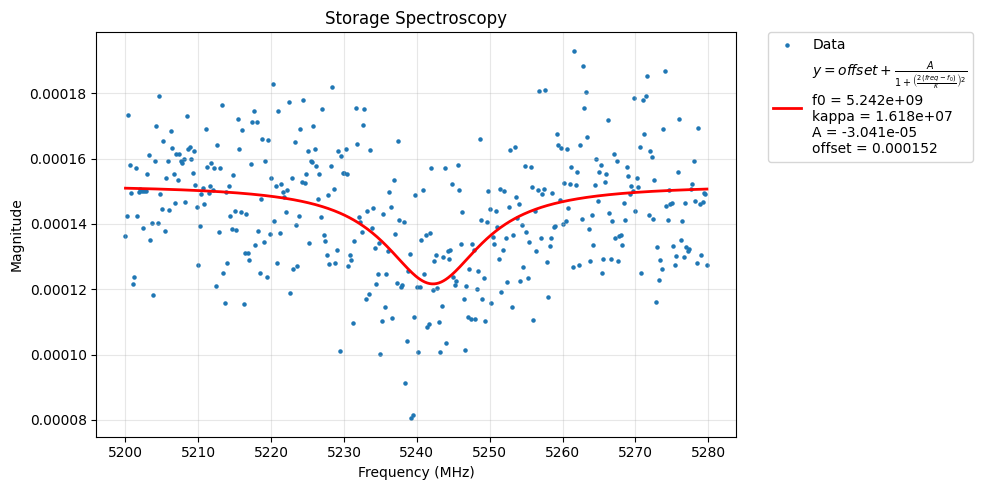

f_storage = 5242.2045 MHz
kappa = 16180.1 kHz


In [9]:
st_spec = StorageSpectroscopy(session)
result = st_spec.run(
    disp="const_alpha",
    rf_begin=5200 * u.MHz,
    rf_end=5280 * u.MHz,
    df=200 * u.kHz,
    storage_therm_time=500,
    n_avg=50,
)

analysis = st_spec.analyze(result, update_calibration=True)
st_spec.plot(analysis)
print(f"f_storage = {analysis.metrics['f_storage'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 8.2 Number Splitting Spectroscopy

Resolve photon-number-dependent qubit frequency shifts.

In [8]:
nsplit = NumSplittingSpectroscopy(session)
result = nsplit.run(
    rf_centers=[attr.qb_fq],
    rf_spans=[10 * u.MHz],
    df=100 * u.kHz,
    n_avg=500,
)

analysis = nsplit.analyze(result)
nsplit.plot(analysis)
print(analysis.metrics)

TypeError: 'NoneType' object is not callable

### 8.3 Storage Chi Ramsey

Measure dispersive coupling chi via Ramsey interferometry.

In [ ]:
# NOTE: StorageChiRamsey requires measureMacro to be configured.
# Run CalibrateReadoutFull (Section 6) before this cell.

chi_ramsey = StorageChiRamsey(session)
result = chi_ramsey.run(
    fock_fq=attr.qb_fq,
    delay_ticks=np.arange(4, 2000, 10),
    disp_pulse="const_alpha",
    x90_pulse="x90",
    n_avg=20,
)

# p0: [P0, A, T2_eff(ns), nbar, chi(1/ns), t0(ns)]
# T2_eff ~ 35 us = 35000 ns;  chi ~ 2.8 MHz = 0.0028/ns;  t0 ~ 0.4 us = 400 ns
analysis = chi_ramsey.analyze(result, update_calibration=True,
                              p0=[0.5, 0.5, 35000, 0.1, 0.0028, 400])
chi_ramsey.plot(analysis)
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")
print(f"nbar = {analysis.metrics.get('nbar', 0):.2f}")

### 8.4 Fock-Resolved Spectroscopy

Probe qubit spectroscopy conditioned on Fock number.

In [7]:
fock_spec = FockResolvedSpectroscopy(session)
result = fock_spec.run(
    probe_fqs=np.linspace(attr.qb_fq - 5e6, attr.qb_fq + 5e6, 101),
    state_prep=None,
    n_avg=20,
)

analysis = fock_spec.analyze(result)
fock_spec.plot(analysis)
print(analysis.metrics)

TypeError: 'NoneType' object is not callable

### 8.5 Fock-Resolved T1

Measure T1 in individual Fock manifolds.

In [ ]:
fock_t1 = FockResolvedT1(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
# To use a subset: fock_fqs = attr.get_fock_frequencies(2)
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_t1.run(
     fock_fqs=fock_fqs,
     fock_disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=200,
     n_avg=20,
)
analysis = fock_t1.analyze(result)
fock_t1.plot(analysis)
for key, val in analysis.metrics.items():
     if key.startswith("T1_fock_"):
         print(f"{key} = {val / 1e3:.2f} us")

### 8.6 Fock-Resolved Ramsey

Measure T2 in individual Fock manifolds.

In [ ]:
fock_ramsey = FockResolvedRamsey(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_ramsey.run(
     fock_fqs=fock_fqs,
     detunings=[0.2e6],
     disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=100,
     n_avg=20,
)
analysis = fock_ramsey.analyze(result)
fock_ramsey.plot(analysis)
print(analysis.metrics)

### 8.7 Fock-Resolved Power Rabi

Calibrate selective pi pulses per Fock manifold.

In [ ]:
fock_rabi = FockResolvedPowerRabi(session)
# fock_fqs = [...]  # From NumSplittingSpectroscopy results
# result = fock_rabi.run(
#     fock_fqs=fock_fqs,
#     gains=np.linspace(0, 1.5, 50),
#     sel_qb_pulse="sel_x180",
#     disp_n_list=["disp_n0", "disp_n1", "disp_n2"],
#     n_avg=2000,
# )
# analysis = fock_rabi.analyze(result)
# fock_rabi.plot(analysis)
# for key, val in analysis.metrics.items():
#     if key.startswith("g_pi_fock_"):
#         print(f"{key} = {val:.4f}")

## 9. Quantum State Tomography

### 9.1 Qubit State Tomography

Three-axis measurement (sigma_x, sigma_y, sigma_z) to reconstruct
the qubit Bloch vector.

2026-02-21 02:21:58,039 - qm - INFO     - Sending program to QOP for compilation
2026-02-21 02:21:58,208 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 9999/10000 [00:01<00:00, 5175.67it/s]

[INFO] 2026-02-21 02:22:00,247 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622592434
No errors


[INFO] 2026-02-21 02:22:00,295 qubox.hardware.program_runner: Job halted successfully.


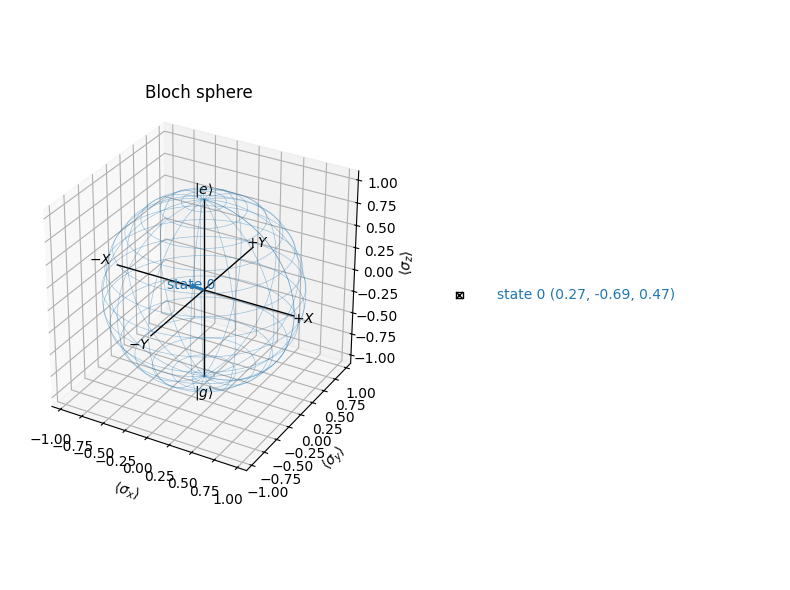

<Figure size 640x480 with 0 Axes>

sx = 0.268
sy = -0.686
sz = 0.466
Purity = 0.759


In [14]:
from qm.qua import *

def prep_x_plus():
    """Prepare |+x> state."""
    play("x90", attr.qb_el)

tomo = QubitStateTomography(session)
result = tomo.run(
    state_prep=prep_x_plus,
    n_avg=10000,
)

analysis = tomo.analyze(result)
tomo.plot(analysis)
print(f"sx = {analysis.metrics.get('sx', 0):.3f}")
print(f"sy = {analysis.metrics.get('sy', 0):.3f}")
print(f"sz = {analysis.metrics.get('sz', 0):.3f}")
print(f"Purity = {analysis.metrics.get('purity', 0):.3f}")

### 9.2 Wigner Tomography

Reconstruct the Wigner function of the storage cavity state.

In [ ]:
wigner = StorageWignerTomography(session)
# Requires gate sequence for state preparation
# result = wigner.run(
#     gates=[...],
#     x_vals=np.linspace(-3, 3, 41),
#     p_vals=np.linspace(-3, 3, 41),
#     n_avg=500,
# )
# analysis = wigner.analyze(result)
# wigner.plot(analysis)
# print(f"W_min = {analysis.metrics.get('W_min', 0):.3f}")
# print(f"W_max = {analysis.metrics.get('W_max', 0):.3f}")
# print(f"Negativity = {analysis.metrics.get('negativity', 0):.3f}")

### 9.3 SNAP Optimization

Optimize SNAP gate angles using Fock-resolved state tomography.

In [ ]:
snap = SNAPOptimization(session)
# result = snap.run(
#     snap_gate=...,
#     disp1_gate=...,
#     fock_probe_fqs=[...],
#     n_avg=500,
# )
# analysis = snap.analyze(result)
# snap.plot(analysis)
# print(analysis.metrics)

## 10. Utility: Continuous-Wave Output

Drive a target element continuously (infinite loop) for diagnostics such as
spectrum analyser alignment or mixer leakage checks. The program runs
indefinitely until manually halted via `job.halt()`.

In [ ]:
from qubox_v2.programs import cQED_programs

# --- CW parameters ---
target_element = attr.qb_el       # element to drive
cw_pulse = "const_x180"           # pulse operation to repeat
cw_gain = 0.5                     # amplitude scaling (0.0 to 1.0)
truncate_clks = 250               # truncate pulse length in clock cycles (1 clk = 4 ns)

# --- Build the infinite-loop program ---
cw_prog = cQED_programs.continuous_wave(
    target_el=target_element,
    pulse=cw_pulse,
    gain=cw_gain,
    truncate_clks=truncate_clks,
)

print(f"Starting CW output on '{target_element}'")
print(f"  pulse      = {cw_pulse}")
print(f"  gain       = {cw_gain}")
print(f"  truncate   = {truncate_clks} clks ({truncate_clks * 4} ns)")
print(f"  This program runs in an INFINITE LOOP.")
print(f"  To stop:  job.halt()")

# Execute directly on the quantum machine
job = session.hw.qm.execute(cw_prog)
print(f"\nJob started: {job.id}")
print("Run 'job.halt()' in the next cell to stop.")

In [ ]:
# --- Stop CW output ---
job.halt()
print("CW output halted.")

---

## Summary

All experiment classes follow the unified `run() -> analyze() -> plot()` protocol:

```python
exp = ExperimentClass(session)
result = exp.run(...)                              # Execute on hardware
analysis = exp.analyze(result, update_calibration=True)  # Fit + extract metrics
exp.plot(analysis)                                 # Visualize
print(analysis.metrics)                            # Inspect extracted parameters
```

Use `update_calibration=True` to automatically persist calibration results
to the `CalibrationStore`.